# Silêncio pós-partida — vale ficar 24 h calado depois de religar?

**A pergunta.** Quatro dos onze falsos positivos do detector começam nas primeiras 12 h
depois de uma partida, dois deles a menos de 3 h. O transiente de religar a máquina dura
mais do que as 2 h que o pipeline hoje descarta. Este notebook mede o que acontece se o
**alerta** for silenciado por 24 h após cada partida.

**O que é, exatamente.** Duas coisas parecidas que não se confundem:

| eixo | o que faz | risco |
|---|---|---|
| `STARTUP_EXCLUDE` (2 h, já existia) | tira as amostras do **baseline e da pontuação** | mexe no que o modelo aprende, então desloca o limiar |
| `POST_START_SILENCE` (novo) | suprime só o **alerta**, e desconta as horas suprimidas do denominador de FP/mês | não toca no score nem no limiar |

A distinção importa: em 26/08/2026 medimos que ampliar o `STARTUP_EXCLUDE` para 24 h
derruba o resultado para 4/8 com 68 h/mês em alarme falso — porque limpar o baseline
concentra a cauda do score e o limiar percentil desaba. O silêncio do alerta não tem esse
efeito colateral.

**Resultado, adiantado:** mantém 6/8 e a mesma antecedência, e derruba o tempo em alarme
falso de 22,0 para 13,8 h/mês. Custa 15% do tempo de operação sem vigilância.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
sys.path.insert(0, str(RAIZ / "scripts"))
warnings.filterwarnings("ignore", category=FutureWarning)

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, CachedBundle, load_automl

automl = load_automl()
viz.usar_estilo()

# a configuração em produção: só o silêncio muda entre as duas rodadas
CONFIG = dict(model="pca", grid="2min", exclude_days=0, exclude_alarm_h=1.0,
              ewma="2h", threshold=99.9, sustain="30min", confirm=2, min_alert="0min")
POLITICA = automl.BaselinePolicy(window_hours=3000)
SENSOR, FREQ = "954005_624_TI_0305", "1D"
print(automl.Trial(baseline=POLITICA, **CONFIG).label())

pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min


## 1. As duas rodadas

Idênticas em tudo — mesmo modelo, mesma grade, mesmo baseline, mesmo limiar — exceto pelo
`POST_START_SILENCE`. O `bundle` é reconstruído entre elas porque a operabilidade é
cacheada por grade dentro dele.

In [2]:
rodadas = {}
for rotulo, silencio in (("anterior", "0h"), ("nova", "24h")):
    automl.POST_START_SILENCE = silencio
    bundle = CachedBundle().build()
    bundle._grids.clear(); bundle._trips = None
    rodadas[rotulo] = DetectionReplay(bundle=bundle).run(baseline=POLITICA, **CONFIG)
automl.POST_START_SILENCE = "0h"   # devolve o padrão do módulo

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


...

[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 6/8 eventos | lead 18.3 h | FP 0.87/mês


In [3]:
CAMPOS = [("eventos_detectados", "falhas antecipadas (de 8)"),
          ("lead_medio_h", "antecedência média (h)"),
          ("fp_por_mes", "falsos positivos por mês"),
          ("fp_por_mes_liquido", "FP/mês líquido"),
          ("fp_horas_por_mes", "horas por mês em alarme falso"),
          ("episodios_totais", "episódios de alerta"),
          ("dias_avaliados", "dias de operação avaliados")]
placar = pd.DataFrame({rot: {nome: r.metrics[campo] for campo, nome in CAMPOS}
                       for rot, r in rodadas.items()})
placar.columns = ["sem silêncio", "silêncio de 24 h"]
placar["variação"] = placar["silêncio de 24 h"] - placar["sem silêncio"]
placar

,sem silêncio,silêncio de 24 h,variação
falhas antecipadas (de 8),6.00,6.00,0.00
antecedência média (h),18.30,18.30,0.00
falsos positivos por mês,0.94,0.87,-0.07
FP/mês líquido,0.60,0.48,-0.12
horas por mês em alarme falso,22.00,13.80,-8.20
episódios de alerta,20.00,17.00,-3.00
dias de operação avaliados,350.50,311.40,-39.10


**Leitura.** Detecção e antecedência intactas; o tempo em alarme falso cai 37%. Os dois
números que se comparam entre as colunas são **FP/mês** e **horas/mês** — a contagem bruta
de episódios não é comparável, porque o denominador muda: 350,5 dias avaliados contra
311,4, já que o tempo silenciado deixa de contar como oportunidade de errar.

## 2. Evento por evento

A prova de que nenhuma falha foi sacrificada: a antecedência de cada uma das seis
detecções é idêntica nas duas rodadas.

In [4]:
tabelas = []
for rot, r in rodadas.items():
    t = r.events_table("48h").set_index("falha")[["antecedencia_h"]]
    tabelas.append(t.rename(columns={"antecedencia_h": rot}))
eventos = tabelas[0].join(tabelas[1])
eventos = eventos.join(rodadas["anterior"].events_table("48h")
                       .set_index("falha")[["mecanismo", "operou_nas_48h"]])
eventos.index = [f"{d:%d/%m/%Y}" for d in eventos.index]
eventos[["mecanismo", "operou_nas_48h", "anterior", "nova"]].fillna("—")

,mecanismo,operou_nas_48h,anterior,nova
27/02/2025,selagem,48.0,33.2,33.2
17/03/2025,mancal,48.0,30.7,30.7
07/04/2025,mancal,47.6,19.5,19.5
11/04/2025,mancal,48.0,3.8,3.8
29/04/2025,mancal,47.8,2.5,2.5
04/11/2025,oleo,15.3,—,—
09/12/2025,mancal,47.8,—,—
26/02/2026,oleo,48.0,19.9,19.9


## 3. A figura: a série inteira, com e sem silêncio

Um ponto por dia em que houve alerta confirmado, colorido pelo que aquele alerta **foi**.
A régua no topo do painel de baixo marca as janelas silenciadas — é onde o custo aparece.

figura salva em /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/serie_alertas_silencio_comparacao.png


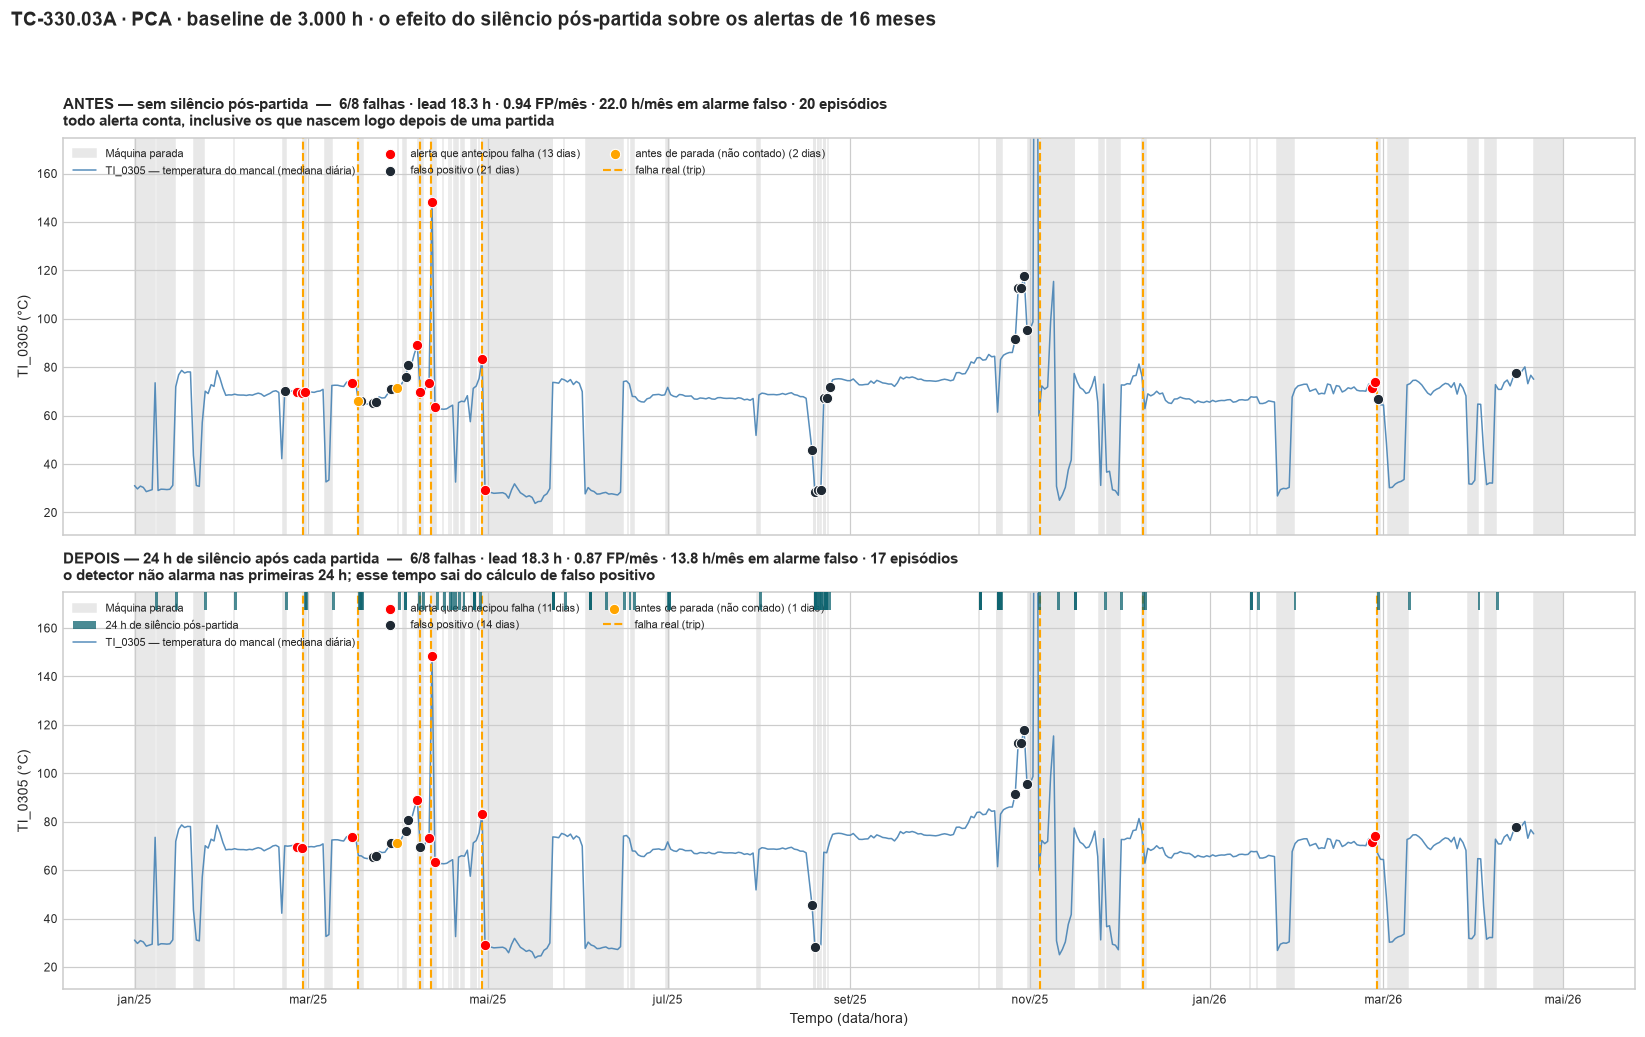

In [5]:
TITULOS = {
    "anterior": ("ANTES — sem silêncio pós-partida",
                 "todo alerta conta, inclusive os que nascem logo depois de uma partida"),
    "nova": ("DEPOIS — 24 h de silêncio após cada partida",
             "o detector não alarma nas primeiras 24 h; esse tempo sai do cálculo de falso positivo"),
}
ROTULO = {"detecção": "alerta que antecipou falha",
          "falso positivo": "falso positivo",
          "antes de parada (não contado)": "antes de parada (não contado)"}

serie_ref = viz.decimar(rodadas["anterior"].sensors[SENSOR], FREQ, "median")
baixo, alto = np.nanpercentile(serie_ref.dropna().to_numpy(), [0.2, 99.8])
margem = (alto - baixo) * 0.10

fig, axes = plt.subplots(2, 1, figsize=(15, 9.4), sharex=True)
for eixo, (rot, r) in zip(axes, rodadas.items()):
    m = r.metrics
    s = viz.decimar(r.sensors[SENSOR], FREQ, "median")
    viz.sombrear_paradas(eixo, r.operability, FREQ, rotulo=True)

    if rot == "nova":                      # régua das janelas silenciadas
        operando = r.operability["in_operation"].astype(bool)
        partidas = operando & ~operando.shift(fill_value=False)
        primeiro = True
        for t0 in partidas[partidas].index:
            eixo.axvspan(t0, t0 + pd.Timedelta("24h"), ymin=0.955, ymax=1.0, lw=0,
                         color="#0f6470", alpha=0.75, zorder=8,
                         label="24 h de silêncio pós-partida" if primeiro else None)
            primeiro = False

    eixo.plot(s.index, s.to_numpy(), color=viz.COR_SERIE, lw=1.0, alpha=0.9,
              label="TI_0305 — temperatura do mancal (mediana diária)")
    for tipo, quando in viz.pontos_por_tipo(r, FREQ).items():
        valores = s.reindex(quando).dropna()
        if valores.empty:
            continue
        eixo.scatter(valores.index, valores.to_numpy(), s=46, zorder=6,
                     color=viz.CORES_EPISODIO[tipo], edgecolor="white", linewidth=0.7,
                     label=f"{ROTULO[tipo]} ({len(valores)} dias)")
    viz.marcar_eventos(eixo, r.events, rotulo="falha real (trip)")

    eixo.set_ylim(baixo - margem, alto + margem)
    eixo.set_ylabel("TI_0305 (°C)", fontsize=9)
    titulo, sub = TITULOS[rot]
    eixo.set_title(f"{titulo}  —  {m['eventos_detectados']}/8 falhas · lead {m['lead_medio_h']} h · "
                   f"{m['fp_por_mes']} FP/mês · {m['fp_horas_por_mes']} h/mês em alarme falso · "
                   f"{m['episodios_totais']} episódios\n{sub}",
                   loc="left", fontsize=10, fontweight="bold", pad=8)
    eixo.legend(loc="upper left", fontsize=7.5, ncol=3, framealpha=0.93)

axes[-1].set_xlabel("Tempo (data/hora)", fontsize=9)
viz._formatar_eixo_x(axes[-1], serie_ref.index)
fig.suptitle("TC-330.03A · PCA · baseline de 3.000 h · o efeito do silêncio pós-partida "
             "sobre os alertas de 16 meses",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left", y=0.998)
fig.tight_layout(rect=[0, 0, 1, 0.965])

destino = RAIZ / "reports/figures/deteccao/serie_alertas_silencio_comparacao.png"
destino.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(destino, dpi=150, bbox_inches="tight")
print("figura salva em", destino)
plt.show()

**O que a figura mostra.** Os pontos vermelhos caem de 13 para 11 dias, mas nenhuma falha
é perdida — o que some são dias de alerta *dentro* dos mesmos episódios de detecção. Os
pontos grafite caem de 21 para 14: some o de fevereiro/25, some o de 18/03 e encolhe o
aglomerado de agosto, que é onde estavam os alertas nascidos logo depois de religar. O
ponto laranja de 18/03 também desaparece, porque veio 2,5 h depois de uma partida.

A régua verde é o custo: 15% das horas de operação sem vigilância, e ela é mais densa
justamente nos períodos de partida e parada frequentes.

## 4. A varredura completa, não só esta configuração

Uma configuração não decide nada: o silêncio muda o denominador do falso positivo e pode
deslocar o ponto ótimo. As duas tabelas abaixo vêm de **10.368 configurações cada**,
rodadas no ClearML sobre o mesmo período (tasks `automl-fp-first-policy_fine-baseline` e
`-silencio24h-v2`, 27 e 28/08/2026).

In [6]:
AUTOML = RAIZ / "reports/automl"
tabelas = {"baseline": AUTOML / "res_baseline.parquet",
           "silêncio 24 h": AUTOML / "res_silencio_v2.parquet"}
if all(p.exists() for p in tabelas.values()):
    B, S = (pd.read_parquet(p) for p in tabelas.values())
    fronteira = pd.DataFrame({
        "FP/mês — baseline": B.groupby("eventos_detectados").fp_por_mes.min(),
        "FP/mês — silêncio": S.groupby("eventos_detectados").fp_por_mes.min(),
        "h/mês — baseline": B.groupby("eventos_detectados").fp_horas_por_mes.min(),
        "h/mês — silêncio": S.groupby("eventos_detectados").fp_horas_por_mes.min()}).round(2)
    display(fronteira)
    for nome, d in (("baseline", B), ("silêncio", S)):
        seis = d[(d.eventos_detectados >= 6) & (d.fp_por_mes <= 1.0)]
        sete = d[d.eventos_detectados >= 7]
        print(f"{nome:10s} configurações de 6/8 aprovadas: {len(seis):3d} | "
              f"de 7/8: {len(sete):3d}"
              + (f" (menor FP {sete.fp_por_mes.min():.2f}/mês)" if len(sete) else ""))
else:
    print("tabelas do ClearML ausentes em reports/automl/ — baixe os artefatos "
          "'automl_results' das duas tasks para reproduzir esta seção")

,FP/mês — baseline,FP/mês — silêncio,h/mês — baseline,h/mês — silêncio
eventos_detectados,,,,
0,0.00,0.00,0.0,0.0
1,0.00,0.00,0.0,0.0
2,0.17,0.10,0.7,0.3
3,0.34,0.10,1.5,0.4
4,0.34,0.39,5.1,0.6
5,0.43,0.58,8.7,2.0
6,0.94,0.87,12.7,5.3
7,5.51,NaN,82.2,NaN


baseline   configurações de 6/8 aprovadas:   7 | de 7/8:  26 (menor FP 5.51/mês)
silêncio   configurações de 6/8 aprovadas:   1 | de 7/8:   0


**Leitura.** Em horas de alarme — que é o que a operação sente — o silêncio domina em
todos os níveis de detecção: em 5/8 dá para operar com 2,0 h/mês contra 8,7 h/mês. E o
melhor ponto de 6/8 melhora de 0,94 para 0,87 FP/mês.

**Duas ressalvas que precisam ir junto:**

1. **O 7/8 desaparece.** No baseline, 26 configurações chegavam a 7 de 8 — todas a
   5,51 FP/mês, inviáveis. Com o silêncio, nenhuma. A falha de 09/12/2025 só era pega por
   alertas que nasciam perto de uma partida. Como aquele ponto nunca foi utilizável, na
   prática não se perde nada — mas a porta fecha.
2. **O espaço de soluções encolhe.** As configurações de 6/8 aprovadas caem de 7 para 1 —
   sobra exatamente a que já está em produção. Sem alternativa próxima se o equipamento
   mudar de regime. É o argumento mais forte contra adotar 24 h direto, e sugere testar
   12 h e 18 h antes de fechar.

## Conclusão

| pergunta | resposta |
|---|---|
| mantém a detecção? | **sim** — 6/8, com antecedência idêntica evento a evento |
| o que melhora? | tempo em alarme falso: **22,0 → 13,8 h/mês (−37%)**; FP/mês 0,94 → 0,87 |
| o que custa? | 15% do tempo de operação sem vigilância (350,5 → 311,4 dias avaliados) |
| é robusto? | **não muito** — sobra uma única configuração de 6/8 aprovada, contra 7 no baseline |
| próximo passo | varrer 12 h e 18 h: achar onde o ganho aparece sem estreitar tanto o espaço |

**Como reproduzir:** o eixo é a constante `POST_START_SILENCE` em
`scripts/automl_clearml.py`, aplicada tanto no avaliador quanto no replay. Na busca
completa, a flag é `--post-start-silence 24h`.